In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import copy
import random
import csv
import rings_utils

import torch
import torch.nn as nn
import torch.distributions as dist
from torch.utils.data import random_split
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [13]:
# 設定亂數種子

seed = 42

torch.manual_seed(seed)           # 設定 CPU 的亂數種子
torch.cuda.manual_seed(seed)      # 設定當前 GPU 的亂數種子
torch.cuda.manual_seed_all(seed)  # 設定所有 GPU 的亂數種子
np.random.seed(seed)              # 設定 numpy 的亂數種子
random.seed(seed)                 # 設定 Python 的亂數種子
# 確保 cuDNN 使用確定性演算法
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
# 查看當前路徑
print(f"Current Path: {os.getcwd()}")

# 設定資料路徑
base_dir = '../rings_generation'
file_name = 'rings(10k_512_10_50).csv'
file_path = os.path.join(base_dir, file_name)
print(f"File Path: {file_path}")
print("-"*60)

# 確保路徑存在
if not os.path.exists(file_path):
    raise FileNotFoundError(f"The file {file_path} does not exist.")

# 讀檔，將資料存入dataset
with open(file_path, 'r') as file:
    dataset = torch.tensor(
        [[float(value) for value in row] for row in csv.reader(file)],
        dtype=torch.float
    ).to(device)
print(f"Dataset Shape: {dataset.shape}")

# 將dataset分為training set跟testing set
total_size = len(dataset)
train_size = int(0.8 * total_size)
test_size = total_size - train_size
dataset_train, dataset_test = random_split(dataset=dataset, lengths=[train_size, test_size])

# 印出結果
print(f"Training Dataset Size: {len(dataset_train)}")
print(f"Testing Dataset Size: {len(dataset_test)}")

Current Path: /home/yihsin/Code/bVAE_mask
File Path: ../rings_generation/rings(10k_512_10_50).csv
------------------------------------------------------------
Dataset Shape: torch.Size([10000, 512])
Training Dataset Size: 8000
Testing Dataset Size: 2000


# 模型

gumbel softmax 的實現可以 PyTorch 已經用 RelaxedOneHotCategorical 包好了（之後改）

In [5]:
class CategoricalVAE(nn.Module):
    
    def __init__(self, input_layer, hidden_layers, N, K):
        
        super().__init__()

        self.N = N
        self.K = K
        
        # Encoder
        layer = []
        in_features = input_layer
        for out_features in hidden_layers:
            layer.append( nn.Linear(in_features, out_features) )
            layer.append( nn.ReLU() )
            in_features = out_features
        layer.append( nn.Linear(in_features, self.N*self.K) )
        self.encoder = nn.Sequential(*layer)
        
        # Decoder
        layer = []
        in_features = self.N*self.K
        for out_features in reversed(hidden_layers):
            layer.append( nn.Linear(in_features, out_features) )
            layer.append( nn.ReLU() )
            in_features = out_features
        layer.append( nn.Linear(in_features, input_layer) )
        layer.append( nn.Sigmoid() )
        self.decoder = nn.Sequential(*layer)
        
    def encode(self, inputs):
        '''
        input
        - inputs.shape: [batch_size, rings_size]
        output
        - logits.shape: [batch_size, N*K]
        '''
        logits = self.encoder(inputs)
        return logits

    def decode(self, latent_codes):
        '''
        input
        - latent_codes.shape: [batch_size, N*K]
        output
        - outputs.shape: [batch_size, rings_size]
        '''
        outputs = self.decoder(latent_codes)
        return outputs

    def gumbel_dist(self, shape, eps=1e-20):
        '''
        input
        - shape.shape: [batch_size, N*K]
        output
        - gumbel_noise.shape: [batch_size, N*K]
        '''
        U = torch.rand(shape).to(device)
        gumbel_noise = -torch.log(-torch.log(U + eps) + eps)
        return gumbel_noise

    def gumbel_softmax(self, logits, temperature):
        '''
        input
        - logits.shape: [batch_size, N*K]
        - temperature.shape: [1]
        output
        - latent_codes.shape: [batch_size, N*K]
        '''
        # Reshape to [batch_size*N, K]
        batch_size = len(logits)
        logits = logits.view(batch_size * self.N, self.K)
        gumbel_noise = self.gumbel_dist(logits.shape)
        y = logits + gumbel_noise
        latent_codes = nn.functional.softmax(y / temperature, dim=-1)

        # Reshape back to [batch_size, N*K]
        logits = logits.view(batch_size, self.N * self.K)
        latent_codes = latent_codes.view(batch_size, self.N * self.K)

        return latent_codes
    
    def forward(self, inputs, temperature):
        '''
        input
        - inputs.shape: [batch_size, rings_size]
        output
        - logits.shape: [batch_size, N*K]
        - latent_codes.shape: [batch_size, N*K]
        - outputs.shape: [batch_size, rings_size]
        '''
        logits = self.encode(inputs)
        latent_codes = self.gumbel_softmax(logits, temperature)
        outputs = self.decoder(latent_codes)
        return logits, latent_codes, outputs

# 訓練

In [6]:
batch_size = 100
epochs = 3
learning_rate = 0.001

T_init = 1.0                                  # initial temperature
T_min = 0.5                                   # minimum temperature
# T_rate = -np.log(T_min / T_init) / (epochs * (1/2))     # 指數模型
# T_rate = (T_min - T_init) / (epochs * (1/2))            # 線性模型
T_rate = 0.0001
print(f"T_rate: {T_rate}")

K = 2     # number of classes
N = 64    # number of categorical distributions

T_rate: 0.0001


In [7]:
# DataLoader
dataloader_train = DataLoader(dataset=dataset_train,
                              batch_size=batch_size,
                              shuffle=False)

In [8]:
# Loss Function
def cat_kl_div(logits):
    '''
    input
    - logits.shape: [batch_size, N*K]
    output
    - kl_loss.shape: []
    '''
    # Reshape to [batch_size*N, K]
    batch_size = len(logits)
    logits = logits.view(batch_size*N, K)
    
    q = dist.Categorical(logits=logits)
    p = dist.Categorical(probs=torch.full(                     # p(z)假設為均勻分布
                                    size=(batch_size*N, K),
                                    fill_value=1.0/K,
                                    device=device
                                )
                        )
    kl = dist.kl.kl_divergence(q, p)    # kl.shape: [batch_size*N]
    kl_loss = torch.mean(kl)            # kl_loss.shape: []
    return kl_loss

def loss_func(outputs, labels, logits, alpha=1, beta=1, gamma=0):
    '''
    input
    - outputs.shape: [batch_size, rings_size]
    - labels.shape: [batch_size, rings_size]
    - logits.shape: [batch_size, N*K]
    output
    - kl_loss.shape: []
    - rec_loss.shape: []
    - loss.shape: []
    '''

    # 重構誤差
    rec_loss = nn.functional.binary_cross_entropy(outputs, labels, reduction="mean")

    # KL散度
    kl_loss = cat_kl_div(logits)

    # 總損失（乘上對應的係數）
    loss = alpha*rec_loss + beta*kl_loss
    
    return rec_loss, kl_loss, loss    # 返回的loss不包括alpha, beta, gamma，
                                      # 這樣才能準確比較這些係數不同時怎麼影響loss

In [9]:
model = CategoricalVAE(512, [300], N, K).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

## 定義儲存、讀取權重的函數

In [10]:
def save_checkpoint(batch, model, optimizer, path="./lucky/checkpoint_batch_{}.pth"):
    '''
    batch代表第幾個batch
    '''
    torch.save({
        'batch': batch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }, path.format(batch))

In [11]:
def load_checkpoint(batch, path="./lucky/checkpoint_batch_{}.pth"):
    checkpoint = torch.load(path.format(batch))
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    return checkpoint['batch']

## 開始訓練

In [12]:
model.train()

# 給一個epoch存一次loss的用（應該要對epoch跟每個epoch的batch做平均）
avg_rec_loss = []
avg_kl_loss  = []
avg_loss     = []

# 給一個batch存一次loss的用（應該要對batch做平均）
batch_rec_loss = []
batch_kl_loss  = []
batch_loss     = []

# alpha, beta, gamma看要每個batch還是每個epoch存一次都可以
alpha_ls     = []
beta_ls      = []
gamma_ls     = []

# 設定初始溫度
temperature = T_init
cnt = 0

for epoch in range(epochs):
    
    total_rec_loss = 0
    total_kl_loss  = 0
    total_loss     = 0
    
    for data in dataloader_train:
        '''
        data.shape: [batch_size, rings_size]
        '''

        # 清空梯度（會不會是這裡導致看到最前面一層的梯度都是0？）
        model.zero_grad()
        
        # 將讀到的data轉成model可以接受的inputs（這個case不用做任何轉變）
        inputs = data
        '''
        inputs.shape: [batch_size, rings_size]
        '''
        
        # 前向傳播
        logits, latent_codes, outputs = model(inputs, temperature)
        '''
        - logits.shape      : [batch_size, N*K]
        - latent_codes.shape: [batch_size, N*K]
        - outputs.shape     : [batch_size, rings_size]
        '''
        
        # 計算loss
        # (alpha, beta, gamma) = (1, 1, 1)
        rec_loss, kl_loss, loss = loss_func(    # 一個batch平均的loss
                                        outputs=outputs,
                                        labels=inputs,
                                        logits=logits,
                                    )
        # total_rec_loss += rec_loss.item()
        # total_kl_loss  += kl_loss.item()
        # total_loss     += loss.item()

        # 一個batch存一次loss
        batch_rec_loss.append( rec_loss.item() )
        batch_kl_loss.append( kl_loss.item() )
        batch_loss.append( loss.item() )
        print(f"{cnt+1:>3}. " \
              f"loss: {loss:.7f}, " \
              f"rec_loss: {rec_loss:.7f}, " \
              f"kl_loss: {kl_loss:.7f}")
        
        # 反向傳播，計算梯度
        loss.backward()

        # 根據梯度更新參數
        optimizer.step()

        # 保存
        cnt += 1
        save_checkpoint(batch=cnt, model=model, optimizer=optimizer)
        
    # T_next = T_init * np.exp(-T_rate*(epoch+1))    # 指數模型
    # T_next = T_rate * epoch + T_init               # 線性模型
    # temperature = np.maximum(T_next, T_min)
    # print(f"{epoch+1:>3}. temperature: {temperature:.2f}")
    
    # 一個epoch平均的loss
    # avg_rec_loss.append( total_rec_loss / len(dataloader_train) )
    # avg_kl_loss.append( total_kl_loss / len(dataloader_train) )
    # avg_loss.append( total_loss / len(dataloader_train) )
    # print(f"{epoch+1:>3}. avg_loss: {avg_loss[epoch]:.7f}, avg_rec_loss: {avg_rec_loss[epoch]:.7f}, avg_kl_loss: {avg_kl_loss[epoch]:.7f}")

  1. loss: 0.7029802, rec_loss: 0.6954806, kl_loss: 0.0074997
  2. loss: 0.6996756, rec_loss: 0.6952553, kl_loss: 0.0044203
  3. loss: 0.6978409, rec_loss: 0.6948336, kl_loss: 0.0030073
  4. loss: 0.6957468, rec_loss: 0.6939377, kl_loss: 0.0018091
  5. loss: 0.6954687, rec_loss: 0.6942842, kl_loss: 0.0011845
  6. loss: 0.6953636, rec_loss: 0.6944810, kl_loss: 0.0008825
  7. loss: 0.6948740, rec_loss: 0.6941755, kl_loss: 0.0006985
  8. loss: 0.6946152, rec_loss: 0.6940211, kl_loss: 0.0005941
  9. loss: 0.6944423, rec_loss: 0.6939766, kl_loss: 0.0004657
 10. loss: 0.6935691, rec_loss: 0.6931859, kl_loss: 0.0003832
 11. loss: 0.6939358, rec_loss: 0.6936018, kl_loss: 0.0003339
 12. loss: 0.6938592, rec_loss: 0.6935672, kl_loss: 0.0002920
 13. loss: 0.6940218, rec_loss: 0.6937565, kl_loss: 0.0002653
 14. loss: 0.6938567, rec_loss: 0.6936169, kl_loss: 0.0002397
 15. loss: 0.6934904, rec_loss: 0.6932648, kl_loss: 0.0002255
 16. loss: 0.6934112, rec_loss: 0.6932002, kl_loss: 0.0002110
 17. los

In [13]:
# 儲存loss數據（還沒加上alpha, beta, gamma）
df = pd.DataFrame({
    "batch_rec_loss": batch_rec_loss,
    "batch_kl_loss": batch_kl_loss,
    "batch_loss": batch_loss
})
df.to_csv("batch_loss.csv", index=False)

## 畫loss-batch curve

x_size: 240


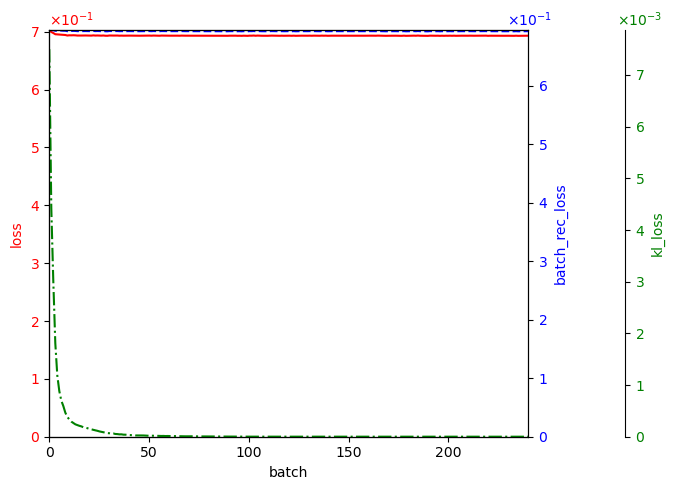

In [14]:
# 定義x軸
x_size = len(batch_loss)
print(f"x_size: {x_size}")
x = np.linspace(0, x_size, x_size)

# 建立圖形和第一個y軸
fig, ax1 = plt.subplots(figsize=(7,5))
# 繪製第一組數據: batch_loss
ax1.plot(x, batch_loss, 'r-', label="loss")
ax1.set_xlabel('batch')
ax1.set_ylabel('loss', color='r')
# ax1.set_yscale('log')
ax1.set_ylim(bottom=0)
ax1.tick_params(axis='y', labelcolor='r')
# 強制 y1 使用科學記號
ax1.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax1.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))  # 強制啟用科學記號
# ax1.get_yaxis().get_offset_text().set_position((, 0))  # 手動移動科學記號標示位置

# 建立第二個y軸: batch_rec_loss
ax2 = ax1.twinx()
ax2.plot(x, batch_rec_loss, 'b--', label="rec_loss")
ax2.set_ylabel('batch_rec_loss', color='b')
ax2.set_ylim(bottom=0)
ax2.tick_params(axis='y', labelcolor='b')
# 強制 y2 使用科學記號
ax2.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))  # 強制啟用科學記號
ax2.get_yaxis().get_offset_text().set_position((1.05, 0))  # 手動移動科學記號標示位置

# 建立第三個y軸: batch_kl_loss
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 70))  # 將第三個y軸移開一點
ax3.plot(x, batch_kl_loss, 'g-.', label="kl_loss")
ax3.set_ylabel('kl_loss', color='g')
ax3.tick_params(axis='y', labelcolor='g')
# 強制 y3 使用科學記號
ax3.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax3.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))  # 強制啟用科學記號
ax3.get_yaxis().get_offset_text().set_position((1.28, 0))  # 手動移動科學記號標示位置

plt.xlim(left=0, right=x_size)
plt.ylim(bottom=0)

# 顯示圖例
fig.tight_layout()  # 確保佈局不重疊
plt.savefig("test.png")
plt.show()

# 推論
測試
- 訓練集跟測試集每個epoch的平均準確率（可能甚至要到batch）
  - 理想情況：訓練集跟測試集的準確率都隨著epoch增加而增加（增加的幅度會越來越慢），訓練集的準確率略高於測試集
  - 過擬合：訓練集的準確率繼續增加，但測試集的準確率下降
- 生成環數要合理、應該所有環數都要生成的到並且是平均的

In [15]:
batch_size = 2000

In [16]:
# DataLoader
dataloader_train = DataLoader(dataset=dataset_train,
                             batch_size=batch_size,
                             shuffle=False)
dataloader_test  = DataLoader(dataset=dataset_test,
                              batch_size=batch_size,
                              shuffle=False)

In [17]:
# Show Image
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

def show_logits(logits):
    '''
    input
    - logits.shape: [batch_size, N*K]
    '''
    sqrtn = int(np.ceil(np.sqrt(logits.shape[0])))
    for index, logit in enumerate(logits):
        plt.subplot(sqrtn, sqrtn, index+1)
        plt.imshow(logit.reshape(N, K))
        plt.axis('off')
    plt.show()

In [18]:
# model.eval()

# with torch.no_grad():
    
#     for data in dataloader_test:
    
#         inputs = data
#         print("inputs.shape:", inputs.shape)
    
#         # Inputs
#         # for i, vector in enumerate(inputs):
#         #     print(f"Batch {i+1}:")
#         #     for j in range(0, len(vector), 10):
#         #         print(vector[j:j+10].int().tolist())
#         #     print("-" * 30)  # 分隔每個 batch
    
#         # Inference/Forward
#         logits, latent_code, outputs = model(inputs, temperature=0.01)
#         '''
#         - logits.shape: [batch_size, N*K]
#         - latent_codes.shape: [batch_size, N*K]
#         - outputs.shape: [batch_size, flatten_img_size]
#         '''
        
#         # Logits
#         # print("logits.shape:", logits.shape)
#         # show_logits(logits)

#         # Latent Code
#         # print("latent_code.shape:", latent_code.shape)
#         # show_logits(latent_code)
        
#         # Outputs
#         outputs = (outputs>=0.5).int().float()
#         # for i, vector in enumerate(outputs):
#         #     print(f"Batch {i+1}:")
#         #     for j in range(0, len(vector), 10):
#         #         print(vector[j:j+10].int().tolist())
#         #     print("-" * 30)  # 分隔每個 batch

#         # 正確率
#         equal_elements = inputs == outputs                          # 比對每個元素是否相等，結果是布林值的 tensor
#         batch_equal_counts = equal_elements.sum(dim=1)              # 對每個 batch 計算相等的元素數量
        
#         # print("每個 batch 中相等的比例")
#         ratio = batch_equal_counts/512*100
#         ratio = ratio.to("cpu").numpy()
#         # for i in range(len(ratio)):
#         #     print(f"{ratio[i]:.0f}", end=', ')
#         #     if i % 10 == 9:
#         #         print("")
#         avg_accuracy = np.mean(ratio)    # 對batch取平均
#         std_accuracy = np.std(ratio)
#         print(f"正確率的平均值：{avg_accuracy:.2f}%")
#         print(f"正確率的標準差：{std_accuracy:.2f}%")

## 測試不同batch的model在training set跟testing set上的正確率

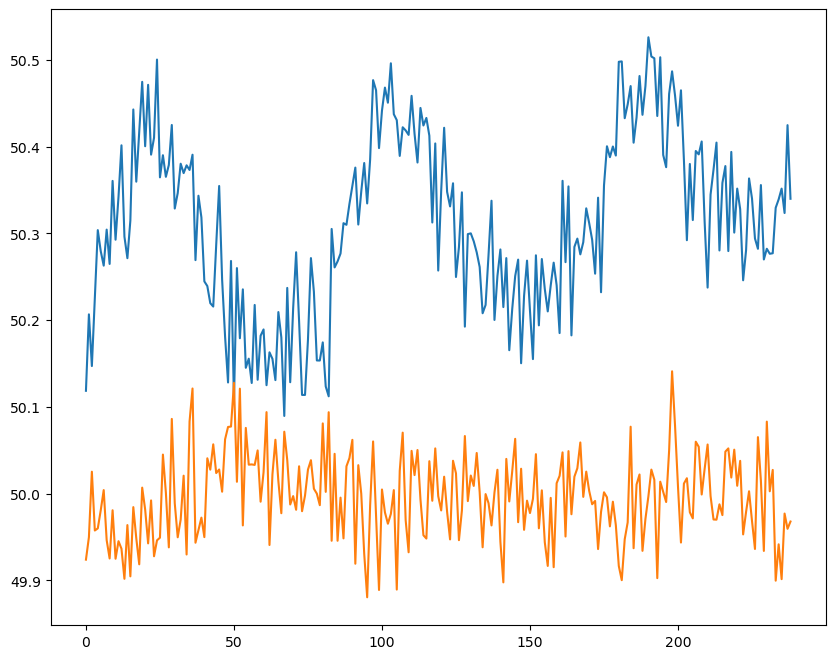

In [19]:
avg_accuracy_train = []
avg_accuracy_test  = []

for i in range(1, x_size):
    checkpoint = torch.load(f"./lucky/checkpoint_batch_{i}.pth", weights_only=True)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    with torch.no_grad():
        
        # training set的數據
        data = next(iter(dataloader_train))
        inputs = data
        logits, latent_code, outputs = model(inputs, temperature=0.01)
        outputs = (outputs>=0.5).int().float()
        # 正確率
        equal_elements = inputs == outputs
        batch_equal_counts = equal_elements.sum(dim=1)
        ratio = batch_equal_counts/512*100
        ratio = ratio.to("cpu").numpy()
        
        avg_accuracy_train.append( np.mean(ratio) )
        
        # testing set的數據
        for data in dataloader_test:
            inputs = data
            logits, latent_code, outputs = model(inputs, temperature=0.01)
            outputs = (outputs>=0.5).int().float()

            # 正確率
            equal_elements = inputs == outputs
            batch_equal_counts = equal_elements.sum(dim=1)

            ratio = batch_equal_counts/512*100
            ratio = ratio.to("cpu").numpy()
            
            avg_accuracy_test.append( np.mean(ratio) )

plt.plot(avg_accuracy_train)
plt.plot(avg_accuracy_test)


tensor(257, device='cuda:0')
ratio: 50.1953125%


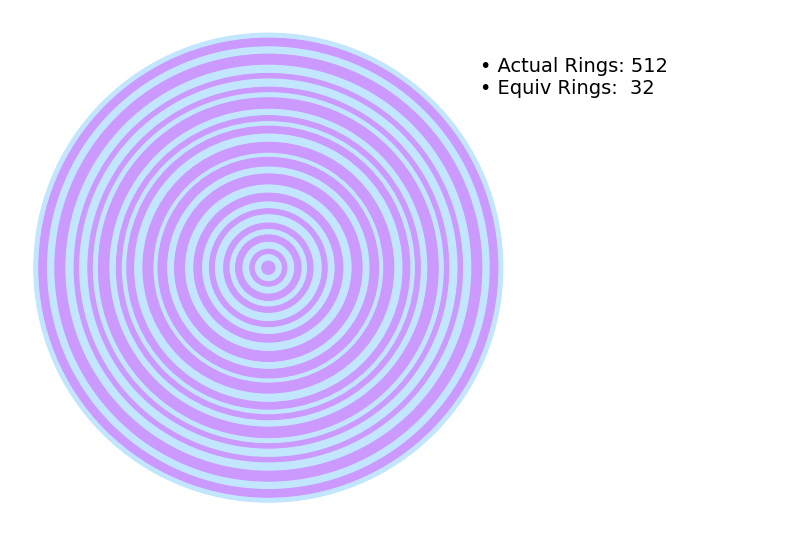

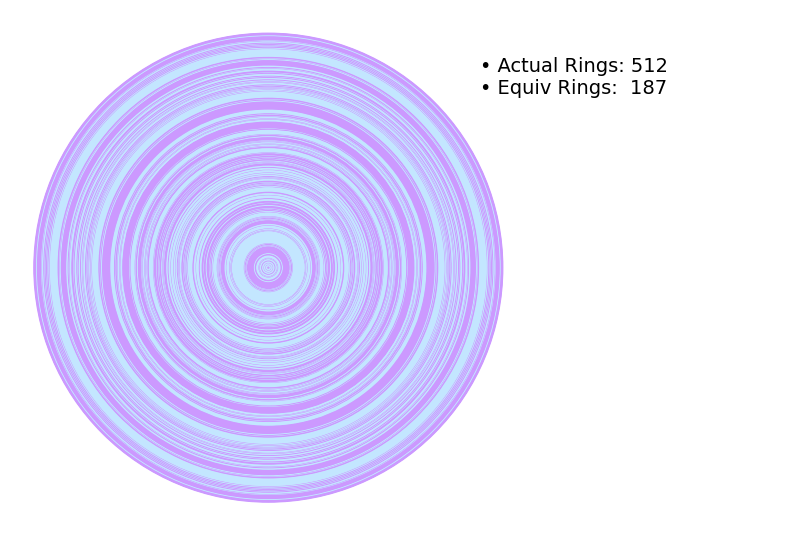

In [20]:
# 畫出等效圖
k = 3
equal_elements = inputs[k] == outputs[k]
equal_elements = equal_elements.sum()
print(equal_elements)
print(f"ratio: {equal_elements/512*100}%")
rings_utils.plot_rings(inputs[k], save=False)
rings_utils.plot_rings(outputs[k], save=False)

# Generation

In [21]:
# 第一個criteria：latent vector變動一點點，output應該也要只能變動一點點

def hamming_dist(str1, str2):
    if len(str1) != len(str2):
        raise ValueError("兩個字串的長度必須相同")
    return sum(c1 != c2 for c1, c2 in zip(str1, str2))

def eval_1(latent_code):
    '''
    latent_code變動一點，看輸出變動多少
    K=2，且要已經binarized
    latent_code.shape: [batch_size, vec_size]    
    '''
    batch_size = len(latent_code)
    vec_size   = len(latent_code[0])

    # 變動一個latent_code的元素（要把它拆成兩半，另一半也要變）
    latent_code_new = latent_code.clone()
    for i in range(batch_size):
        idx_front = random.randint(1, vec_size//2) - 1
        idx_rear  = idx_front + vec_size//2
        latent_code_new[i][idx_front] = 0.0 if latent_code_new[i][idx_front] == 1.0 else 1.0
        latent_code_new[i][idx_rear]  = 0.0 if latent_code_new[i][idx_rear] == 1.0 else 1.0

    # 計算輸出的差異
    outputs     = model.decode(latent_code)
    outputs     = (outputs>=0.5).int().float()
    outputs_new = model.decode(latent_code_new)
    outputs_new = (outputs_new>=0.5).int().float()
    
    diff = []
    for i in range(batch_size):
        diff.append(hamming_dist(outputs[i], outputs_new[i]) / 512 * 100)    # 不同輸出的比例%
    diff = np.array( [tensor.item() for tensor in diff] )    # diff.shape: [batch_size]

    # 畫環
    k=1
    rings_utils.plot_rings(outputs[k], save=False)
    rings_utils.plot_rings(outputs_new[k], save=False)
    
    avg_diff = np.mean(diff)
    std_diff = np.std(diff)
    return avg_diff, std_diff
    
    # # 畫直方圖統計
    # bins = range(0, 100, 1)  # 從0到30，每5為一個區間
    
    # # 繪製直方圖
    # plt.hist(diff, bins=bins, edgecolor='black')
    # plt.title('Histogram of diff')
    # plt.xlabel('Value Range')
    # plt.ylabel('Frequency')
    # plt.xticks(bins)  # 設置x軸的刻度
    # plt.grid(axis='y', linestyle='--', alpha=0.7)
    # plt.show()

In [22]:
# 第二個criteria：假設rec_loss夠好，隨機抽樣一筆latent vector再經過decoder, encoder回來得到的latent vector比對後就可以評斷decoder的好壞

def eval_2(latent_code):
    pass
    # inputs = outputs
    # latent_code_new = model.encode(inputs)

    # latent_code_new = (latent_code_new>=0.5).int().float()
    # # 正確率
    # equal_elements = latent_code == latent_code_new             # 比對每個元素是否相等，結果是布林值的 tensor
    # batch_equal_counts = equal_elements.sum(dim=1)              # 對每個 batch 計算相等的元素數量
    # print("每個 batch 中相等的元素數量：", batch_equal_counts)
    # print("每個 batch 中相等的元素比例：", batch_equal_counts/len(latent_code[0]))

In [23]:
# 第三個criteria：判斷書出的環數有沒有小於threshold（但是有可能小小的出錯就讓他多了很多等校環）
def eval_3(latent_code):
    '''
    input
    - latent_code.shape: [batch_size, vec_size]
    '''
    outputs = model.decode(latent_code)
    outputs = (outputs>=0.5).int().float()
    
    nums = []    # 紀錄每個batch的等效環數
    for i in range(len(latent_code)):
        nums.append( rings_utils.equiv_rings(outputs[i]) )
        # print(f"等效環數：{nums[i]}")
    nums = np.array(nums)
    
    avg_nums = np.mean(nums)    # 等效環數的平均值
    std_nums = np.std(nums)     # 等效環數的標準差
    return avg_nums, std_nums

變化比例的平均值：8.15%
變化比例的標準差：2.47%
------------------------------------------
等效環數的平均值：193.10
等效環數的標準差：15.67


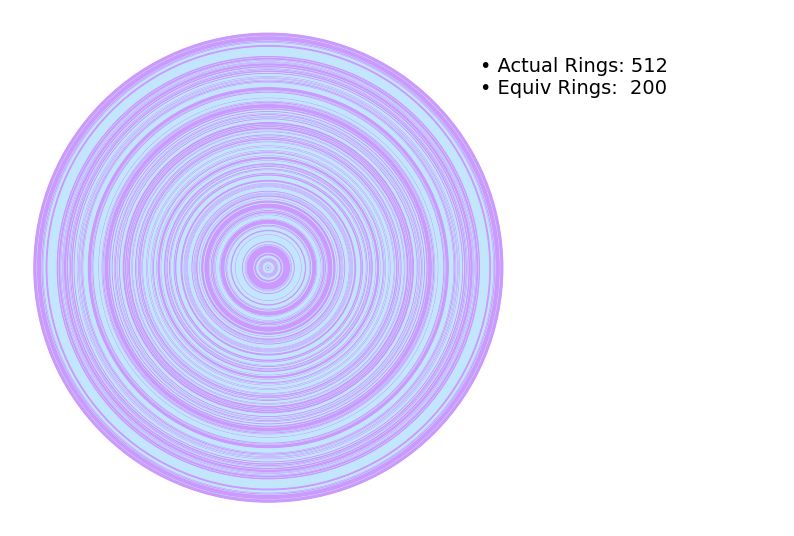

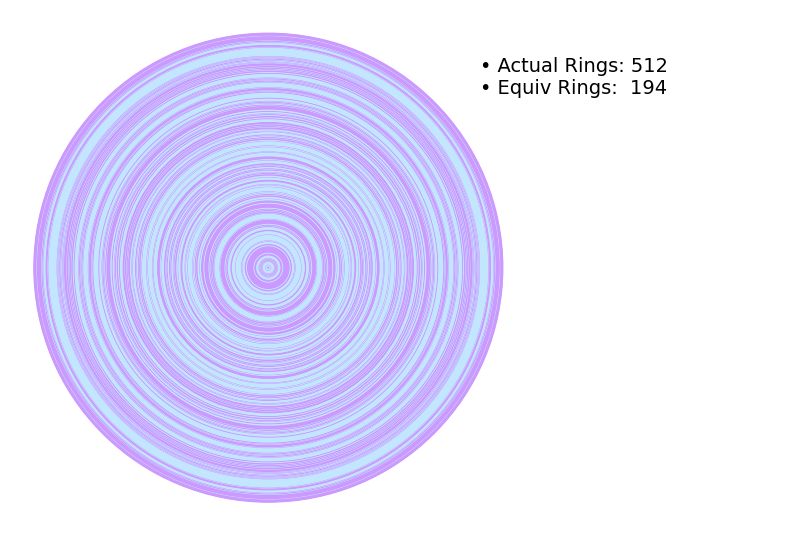

In [24]:
batch_size = 1000
temperature = 0.01
with torch.no_grad():
    logits = torch.rand((batch_size, N, K), device=device)
    latent_code = model.gumbel_softmax(logits, temperature)
    latent_code = (latent_code>=0.5).int().float()

    # 評估生成模型的好壞
    avg_diff, std_diff = eval_1(latent_code)
    print(f"變化比例的平均值：{avg_diff:.2f}%")    # 正常情況應該10%左右
    print(f"變化比例的標準差：{std_diff:.2f}%")    # 應該要盡量小ㄅ

    print("------------------------------------------")
    
    avg_nums, std_nums = eval_3(latent_code)
    print(f"等效環數的平均值：{avg_nums:.2f}")    # 正常情況應該要小於50，極限就是超過50一點
    print(f"等效環數的標準差：{std_nums:.2f}")    # 應該要盡量小ㄅ